5.2 위키피디아
- 문서 검색, 요약, 전체 페이지 가져오기 등의 기능을 제공

In [2]:
!pip install wikipedia

In [3]:
import wikipedia
import os
import re
import requests
from urllib.parse import quote

#위키피디아에서 가져올 문서 목록
wiki_titles = [
    "Water Lilies (Monet series)",
    "The Starry Night",
    "Where Do We Come From? What Are We? Where Are We Going?",
    "The Card Players",
    "Bedroom in Arles",
    "Cafe Terrace at Night",
    "Woman in the Garden",
    "Impression, Sunrise",
    "The Kiss (Klimt)",
]
#다운로드한 파일을 저장할 폴더 생성
output_folder = "wiki_downloads"
os.makedirs(output_folder, exist_ok=True)

def download_wikipedia_page(title):
    """위키피디아 문서를 다운로드하여 텍스트 파일로 저장""" 
    try:
        page = wikipedia.page(title)
        title = title.replace(" ", "_")
        file_path = os.path.join(output_folder, f"{title}.txt")
        with open(file_path, "w", encoding="utf-8") as f:
            f.write(page.content)
        print(f"Saved wikipedia article: {file_path}")
        return file_path
    except Exception as e:
        print(f"Error downloading page '{title}:{str(e)}")
        return None

def get_wikidata_id(title):
    """위키피디아 문서에서 위키데이터 ID 조회"""
    #문서 제목을 URL에 사용할 수 있도록 인코딩(공백 등 특수문자 처리)
    encoded_title = quote(title)
    wiki_api_url = f"https://en.wikipedia.org/w/api.php?action=query&titles={encoded_title}&prop=pageprops&format=json"
    #요청을 보낼때 User-Agent 없이 요청하면 차단됨
    headers = {"User-Agent":"Mozilla/5,0"}
    #위키피디아 API에 Get요청을 보내고 응답을 받아옴
    response = requests.get(wiki_api_url, headers=headers)

    #응답 상태가 200이면 정상이지만, 아니면 오류 처리
    if response.status_code != 200:
        print(f"Failed to fetch wikidata ID for {title}. HTTP Status:{response.status_code}")
        return None
    
    data = response.json()
    #Json 데이터에서 'query' -> 'pages' 키를 찾아 문서 저장 가져오기
    pages = data.get("query", {}).get("pages", {})
    #페이지 정보에서 'pageprops' 내 'wikibase_item' 속성을 찾아 위키데이터 ID(QID) 추출
    for page_id, page_data in pages.items():
        if "pageprops" in page_data and "wikibase_item" in page_data["pageprops"]:
            return page_data["pageprops"]["wikibase_item"]

In [4]:
import hashlib

def get_md5_path(filename):
    #파일명에서 공백을 제거하고 첫 글자를 소문자로 변환
    filename_normalized = filename.replace(' ', '_')

    #MD5 해시 생성
    md5 = hashlib.md5(filename_normalized.encode('utf-8')).hexdigest()
    return f"{md5[0]}/{md5[0:2]}/{filename_normalized}"

In [5]:
def get_infobox_image(wikidata_id):
    """위키데이터레서 대표이미지 URL 가져오기"""
    if not wikidata_id:
        return None
    
    wikidata_url = f"https://www.wikidata.org/wiki/Special:EntityData/{wikidata_id}.json"
    headers = {"User-Agent":"Mozilla/5.0"}
    response = requests.get(wikidata_url, headers=headers)

    #응답 상태가 200이면 정상이지만, 아니면 오류 처리
    if response.status_code != 200:
        print(f"Failed to fetch wikidata ID for {wikidata_id}. HTTP Status:{response.status_code}")
        return None
    
    #응답 데이터를 json 형식으로 변환
    data = response.json()
    #'entities' 딕셔너리에서 특정 wikidata id에 해당하는 데이터 가져오기
    entity = data.get("entities", {}).get(wikidata_id, {})
    #'claims' 힝목에서 속성 정보 가져오기(각종 메타데이터 포함)
    claims = entity.get("claims", {})

    #'p18' 속성이 존재한느지 확인(대표이미지 속성)
    if "P18" in claims:
        image_filename = claims["P18"][0]["mainsnak"]["datavalue"]["value"]
        #이미지 파일명을 위키미디어 URl 형식으로 변환(MD5 해싱 적용)
        md5_path = get_md5_path(image_filename)
        #최종적으로 위키미디어 공용(wikimedia commons)에서 접근 가능한 이미지 URL 반환
        return f"https://upload.wikimedia.org/wikipedia/commons/{md5_path}"
    return None

In [6]:
import requests
from PIL import Image
from io import BytesIO

def sanitize_filename(title):
    """파일명에서 특수문자를 제거하고 안전한 형식으로 변환"""
    return re.sub(r'[^a-zA-Z0-9_-]', '_', title)

def download_image(url, title, max_size=800):
    if not url:
        print(f"No image found for {title}")
        return None
    
    try:
        #PIL 라이브러리 임포트
        Image.MAX_IMAGE_PIXELS = None #DecompressionBomb 에러 방지

        headers = {"User-Agent":"Mozilla/5.0"}
        response = requests.get(url, headers=headers)
        response.raise_for_status()

        #이미지 열기
        img = Image.open(BytesIO(response.content))

        #원본 크기 확인
        width, height = img.size
        print(f"Original size: {width}X{height}")

        #리사이징 필요 여부 확인
        if width > max_size or height > max_size:
            #비율 유지하면서 리사이징
            if width > height:
                new_width = max_size
                new_height = int(height * (max_size / width))
            else:
                new_height = max_size
                new_width = int(width * (max_size / height))

            try:
                #고품질 리사이징(LANCZOS)
                img.thumbnail((new_width, new_height), Image.Resampling.LANCZOS)
                print(f"Resized to:{new_width}X{new_height}")
            except Exception as e:
                img.thumbnail((new_width, new_height), Image.Resampling.NEAREST)
                print(f"Error during resize, trying with NEAREST resampling:{str(e)}")
        
        #이미지 저장
        safe_title = sanitize_filename(title)
        image_path = os.path.join(output_folder, f"{safe_title}.jpg")

        #JPEG로 저장(품질 85%)
        img.convert('RGB').save(image_path, 'JPEG', quality=85)
        print(f"Downloaded and saved image: {image_path}")
        return image_path
    except requests.exceptions.RequestException as e:
        print(f"Filed to download image for {title}. Error:{str(e)}")

        #썸네일 URL이 실패하면 원본 URL로 재시도
        if "thumb" in url:
            original_url = url.split("/thumb/")[0]+"/"+url.split("/thumb/")[1].split("/")[0]
            print(f"Trying original URL: {original_url}")
            return download_image(original_url, title, max_size)
        return None
    except Exception as e:
        print(f"Error processing image for {title}. Error:{str(e)}")
        return None


In [7]:
for title in wiki_titles:
    text_path = download_wikipedia_page(title)

    if text_path:
        wikidata_id = get_wikidata_id(title)
        image_url = get_infobox_image(wikidata_id)
        download_image(image_url, title)

Saved wikipedia article: wiki_downloads/Water_Lilies_(Monet_series).txt
Original size: 5472X3648
Resized to:800X533
Downloaded and saved image: wiki_downloads/Water_Lilies__Monet_series_.jpg
Saved wikipedia article: wiki_downloads/The_Starry_Night.txt
Original size: 30000X23756
Resized to:800X633
Downloaded and saved image: wiki_downloads/The_Starry_Night.jpg
Saved wikipedia article: wiki_downloads/Where_Do_We_Come_From?_What_Are_We?_Where_Are_We_Going?.txt
Original size: 3090X1175
Resized to:800X304
Downloaded and saved image: wiki_downloads/Where_Do_We_Come_From__What_Are_We__Where_Are_We_Going_.jpg
Saved wikipedia article: wiki_downloads/The_Card_Players.txt
Original size: 1683X1385
Resized to:800X658
Downloaded and saved image: wiki_downloads/The_Card_Players.jpg
Saved wikipedia article: wiki_downloads/Bedroom_in_Arles.txt


KeyboardInterrupt: 

5.6 이미지 기반 RAG 시스템 구축
- 라마인덱스와 쿼드런트를 활용해 이미지 검색 수행
- 입력 이미지와 가장 유사한 이미지를 데이터베이스에서 찾아내는 과정

In [8]:
import os

wiki_titles = [
    "Nave nave moe"
]

output_folder = "wiki_downloads2"
os.makedirs(output_folder, exist_ok=True)

for title in wiki_titles:
    text_path = download_wikipedia_page(title)

    if text_path:
        wikidata_id = get_wikidata_id(title)
        image_url = get_infobox_image(wikidata_id)
        
        if(image_url):
            print(f"해당 URL로부터 다운로드를 진행 중입니다: {image_url}")
            download_image(image_url, title)

Saved wikipedia article: wiki_downloads2/Nave_nave_moe.txt
해당 URL로부터 다운로드를 진행 중입니다: https://upload.wikimedia.org/wikipedia/commons/9/95/Paul_Gauguin_068.jpg
Original size: 4356X3304
Resized to:800X606
Downloaded and saved image: wiki_downloads2/Nave_nave_moe.jpg


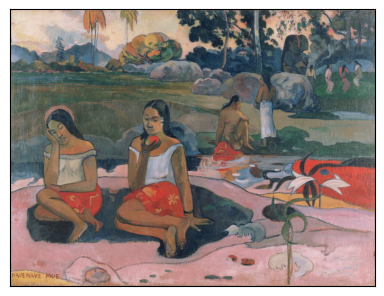

In [10]:
!pip install matplotlib
import matplotlib.pyplot as plt
from PIL import Image

def plot_images(image_paths):
    images_shown = 0
    plt.figure(figsize=(16,9))
    for img_path in image_paths:
        if os.path.isfile(img_path):
            image = Image.open(img_path)

            plt.subplot(2,3, images_shown+1)
            plt.imshow(image)
            plt.xticks([])
            plt.yticks([])

            images_shown += 1
            if images_shown >= 9:
                break

input_image = "wiki_downloads2/Nave_nave_moe.jpg"
plot_images([input_image])